In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data= pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [5]:
Y_train 

array([6, 4, 9, ..., 8, 0, 4])

In [6]:
X_train.shape

(784, 41000)

In [7]:
X_train[0].shape

(41000,)

In [8]:
def init_params ():
    W1 = np.random.randn(10,784) * 0.01
    b1 = np.zeros((10,1))
    W2 = np.random.randn(10,10) * 0.01
    b2 = np.zeros((10,1))
    return W1, b1, W2, b2
#function for the initial parameters for forward propagation

In [9]:
def ReLU(Z):
    return np.maximum(Z, 0)
#defining rectified linear unit or ReLU activation function 

In [10]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    A = np.exp(Z_shifted) / np.sum(np.exp(Z_shifted), axis=0, keepdims=True)
    return A

In [11]:
def forward_prop (W1, b1, W2, b2, X):
    Z1= W1.dot(X)+b1
    A1= ReLU(Z1)
    Z2= W2.dot(A1)+b2
    A2= softmax(Z2)
    return Z1, A1, Z2, A2
# creating my forward propagation function do obtain initial prediction 

In [12]:
Y_train.size

41000

In [13]:
def one_hot(Y):
    one_hot_Y= np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y]=1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
#one-hot function to turn our data into an array 

In [14]:
def deriv_ReLU(Z): 
    return Z>0 
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    m = Y.size
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, 1)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, 1)
    return dW1, db1, dW2, db2
# backward propagateion function defined as well as g' aka the derivative of our activation function ReLU

In [15]:
def update_params (W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1= W1 - alpha*dW1
    b1= b1 - alpha*db1.reshape(-1, 1)
    W2= W2 - alpha*dW2
    b2= b2 - alpha*db2.reshape(-1, 1)
    return W1, b1, W2, b2
#update parameters so that the cycle can restart with our errors lessened

In [16]:
def get_preds (A2):
    return np.argmax(A2, 0)

In [17]:
def get_acc(preds, Y):
    print(preds, Y)
    return np.sum(preds==Y)/Y.size

In [18]:
def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            preds = get_preds(A2)
            print(get_acc(preds, Y))
    return W1, b1, W2, b2
                                   

In [19]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[1 1 1 ... 6 4 1] [6 4 9 ... 8 0 4]
0.1314390243902439
Iteration:  10
[1 1 1 ... 1 1 1] [6 4 9 ... 8 0 4]
0.1296829268292683
Iteration:  20
[1 1 1 ... 3 1 1] [6 4 9 ... 8 0 4]
0.15004878048780487
Iteration:  30
[1 1 1 ... 3 1 1] [6 4 9 ... 8 0 4]
0.1866341463414634
Iteration:  40
[1 1 1 ... 3 1 1] [6 4 9 ... 8 0 4]
0.20151219512195123
Iteration:  50
[3 1 1 ... 3 2 3] [6 4 9 ... 8 0 4]
0.188
Iteration:  60
[3 1 1 ... 3 0 3] [6 4 9 ... 8 0 4]
0.252390243902439
Iteration:  70
[3 8 7 ... 3 0 1] [6 4 9 ... 8 0 4]
0.3688780487804878
Iteration:  80
[8 9 7 ... 3 0 7] [6 4 9 ... 8 0 4]
0.43009756097560975
Iteration:  90
[8 9 9 ... 3 0 9] [6 4 9 ... 8 0 4]
0.4789024390243902
Iteration:  100
[6 9 7 ... 3 0 7] [6 4 9 ... 8 0 4]
0.5355365853658537
Iteration:  110
[6 9 7 ... 3 0 7] [6 4 9 ... 8 0 4]
0.6008536585365853
Iteration:  120
[6 4 7 ... 3 0 7] [6 4 9 ... 8 0 4]
0.6530487804878049
Iteration:  130
[6 4 7 ... 3 0 7] [6 4 9 ... 8 0 4]
0.6896341463414634
Iteration:  140
[6 4 7 ... 3

In [20]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_preds(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [8]
Label:  8


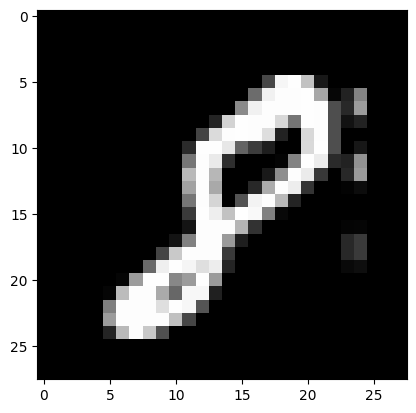

In [21]:
test_prediction(5, W1, b1, W2, b2)

In [22]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_acc(dev_predictions, Y_dev)
accuracy = get_acc(dev_predictions, Y_dev)
print(f"Dev Accuracy: {accuracy * 100:.1f}%")

[0 9 3 0 6 1 2 8 3 4 0 0 5 7 3 9 0 5 3 3 3 9 5 8 9 8 5 4 4 0 2 8 7 9 2 6 6
 3 6 8 7 7 8 4 1 3 3 0 8 1 4 4 2 1 9 8 6 1 2 9 6 0 4 8 6 6 2 2 4 5 0 0 9 4
 7 1 8 5 9 6 2 4 3 2 7 9 1 8 7 3 0 1 7 9 8 1 3 3 5 3 3 1 7 1 1 6 6 7 5 9 7
 4 9 2 8 8 6 0 7 9 3 8 0 2 5 4 5 4 7 4 3 5 9 1 0 4 9 3 3 0 1 9 1 2 4 1 4 3
 3 6 7 4 0 9 3 8 4 3 4 5 3 5 8 9 1 0 5 7 9 6 2 0 9 7 8 8 9 5 1 7 9 8 0 7 9
 1 6 3 3 4 6 1 8 6 3 3 2 9 9 8 0 4 8 9 7 3 9 5 6 8 8 3 4 4 9 0 0 1 3 6 9 5
 3 2 1 8 1 4 7 1 0 2 3 5 2 1 1 4 1 6 0 6 1 1 1 4 6 5 8 5 9 0 6 5 4 9 7 4 7
 0 6 8 7 3 0 4 5 8 1 0 4 4 0 0 7 0 1 3 3 5 8 2 2 4 3 2 3 3 9 5 0 9 8 2 5 7
 3 4 6 4 0 8 5 2 2 8 2 8 4 1 0 4 9 0 9 7 2 3 7 8 0 3 5 5 1 4 0 9 2 6 6 5 7
 7 6 1 5 8 4 2 2 8 3 9 4 7 9 5 6 2 6 5 0 8 0 7 0 2 7 4 6 0 4 7 3 3 5 8 8 8
 4 7 3 7 9 6 5 6 2 1 7 1 1 4 6 4 4 0 8 4 6 7 7 6 7 8 5 3 3 1 4 1 4 3 8 0 0
 5 0 2 4 0 7 7 7 4 1 1 5 0 7 6 5 9 5 2 9 3 1 8 0 9 3 9 9 6 8 1 2 7 0 3 9 6
 1 3 2 2 5 1 4 0 3 7 9 6 1 7 6 2 4 6 5 4 1 2 9 9 0 2 1 2 1 5 1 8 3 2 2 7 5
 0 7 1 1 9 5 3 8 6 1 9 4 

In [23]:

test_data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')
X_test = np.array(test_data).T / 255.

test_preds = make_predictions(X_test, W1, b1, W2, b2)


submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_preds) + 1),
    "Label": test_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,7
4,5,2
